In [20]:
"""
Ejemplo de tratamiento de datos faltantes y outliers
usando el archivo titanic.csv.

Requisitos:
- pandas
- numpy
- scikit-learn
- matplotlib
- seaborn
- scipy
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from scipy import stats


# -------------------------------------------------------------------
# 1. Cargar datos
# -------------------------------------------------------------------
# Ajustar la ruta al archivo
df = pd.read_csv("/content/drive/MyDrive/titanic.csv")

# Copia de trabajo
data = df.copy()

print("Primeras filas:")
print(data.head())
print("\nResumen de valores faltantes por columna:")
print(data.isna().sum())

# -------------------------------------------------------------------
# 2. Eliminación de datos faltantes
#    2.1 Listwise deletion (eliminar filas con cualquier NA)
# -------------------------------------------------------------------
listwise_df = data.dropna()
print("\nTamaño original:", data.shape)
print("Tamaño tras listwise deletion:", listwise_df.shape)



Primeras filas:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N


Correlación (pairwise) entre variables numéricas:
            Age      Fare     SibSp     Parch
Age    1.000000  0.096067 -0.308247 -0.189119
Fare   0.096067  1.000000  0.159651  0.216225
SibSp -0.308247  0.159651  1.000000  0.414838
Parch -0.189119  0.216225  0.414838  1.000000


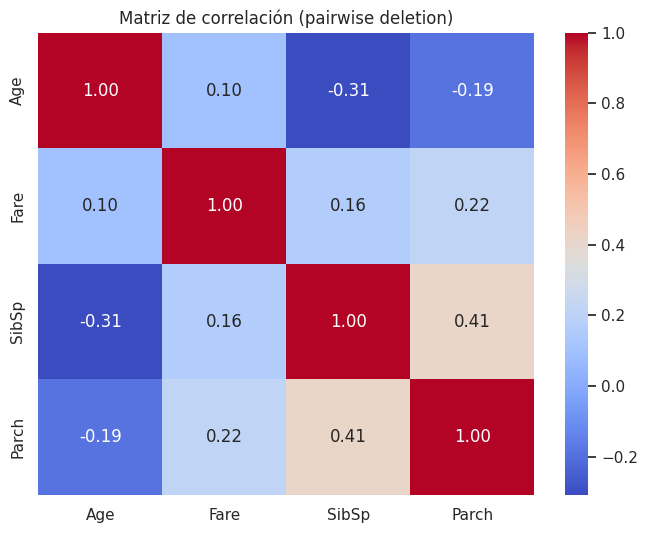

In [21]:
# -------------------------------------------------------------------
# 2.2 Pairwise deletion (ejemplo en un análisis de correlación)
#     Pairwise no crea un nuevo DataFrame, sino que usa pares válidos
# -------------------------------------------------------------------
# Seleccionamos algunas variables numéricas
num_cols = ["Age", "Fare", "SibSp", "Parch"]

# Correlación con pairwise (pandas ya usa pares válidos por defecto)
pairwise_corr = data[num_cols].corr()  # pairwise por defecto
print("\nCorrelación (pairwise) entre variables numéricas:")
print(pairwise_corr)

plt.figure(figsize=(8,6))
sns.heatmap(pairwise_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (pairwise deletion)")
plt.show()


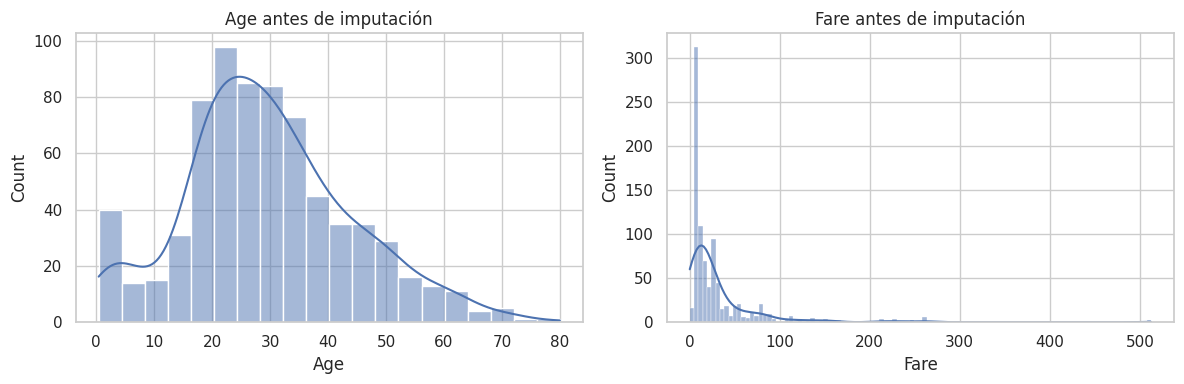

/tmp/ipykernel_6639/482841679.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mode_df[col].fillna(mode_value, inplace=True)
/tmp/ipykernel_6639/482841679.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

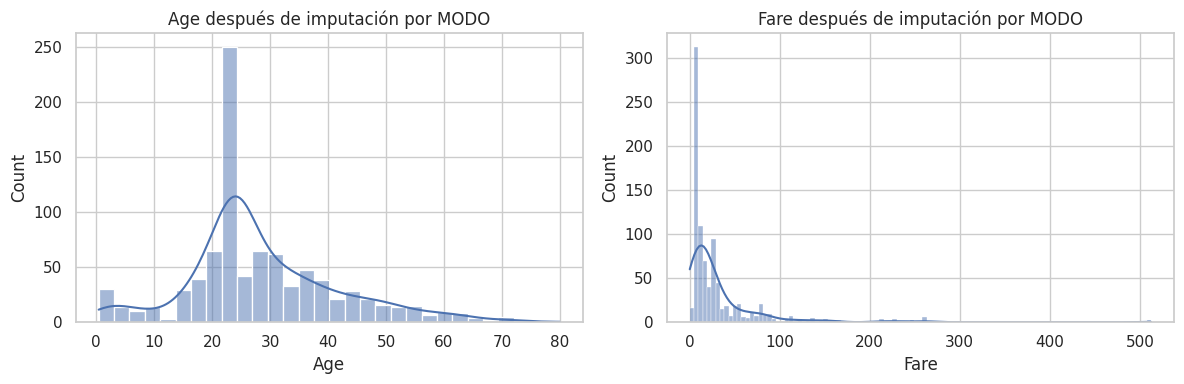

/tmp/ipykernel_6639/482841679.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  median_df[col].fillna(median_df[col].median(), inplace=True)


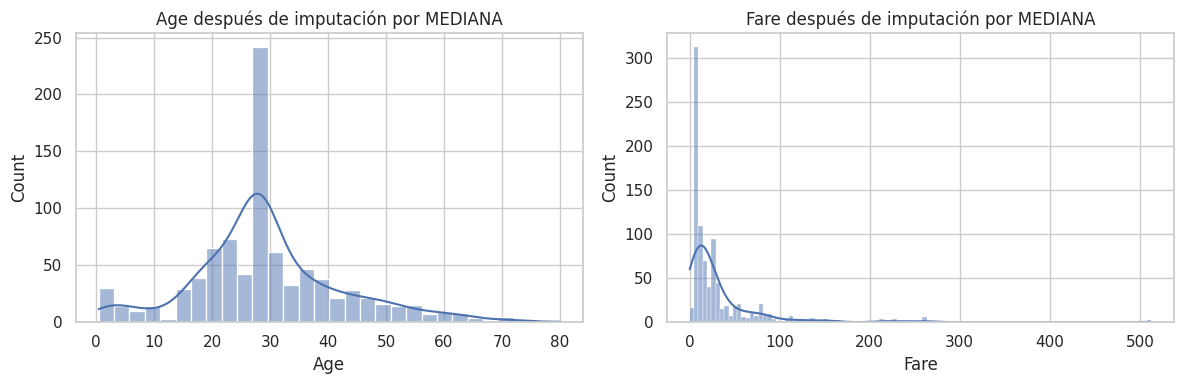

/tmp/ipykernel_6639/482841679.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean_df[col].fillna(mean_df[col].mean(), inplace=True)


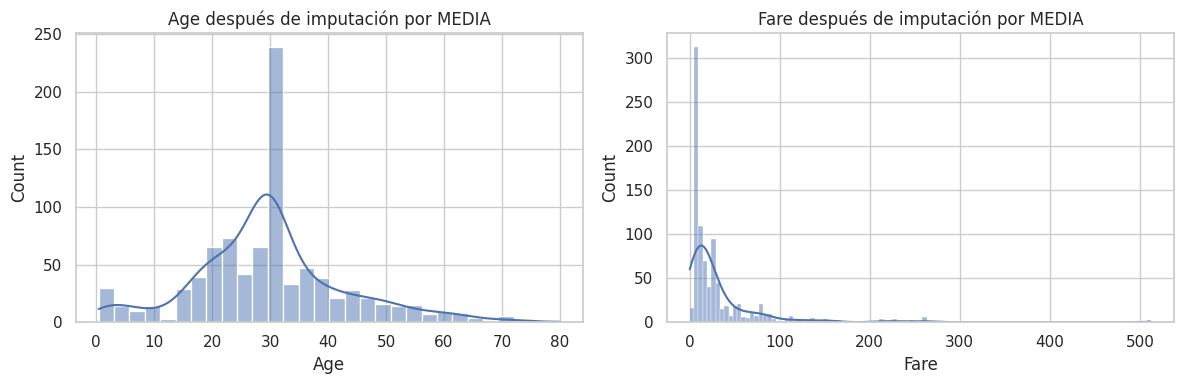

In [23]:

# -------------------------------------------------------------------
# 2. Gráficas ANTES de imputar
# -------------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data["Age"], kde=True)
plt.title("Age antes de imputación")

plt.subplot(1,2,2)
sns.histplot(data["Fare"], kde=True)
plt.title("Fare antes de imputación")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3. IMPUTACIÓN POR MODO
# -------------------------------------------------------------------
mode_df = data.copy()

for col in num_cols:
    mode_value = mode_df[col].mode(dropna=True)[0]
    mode_df[col].fillna(mode_value, inplace=True)

# Gráficas después de imputación por modo
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(mode_df["Age"], kde=True)
plt.title("Age después de imputación por MODO")

plt.subplot(1,2,2)
sns.histplot(mode_df["Fare"], kde=True)
plt.title("Fare después de imputación por MODO")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4. IMPUTACIÓN POR MEDIANA
# -------------------------------------------------------------------
median_df = data.copy()

for col in num_cols:
    median_df[col].fillna(median_df[col].median(), inplace=True)

# Gráficas después de imputación por mediana
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(median_df["Age"], kde=True)
plt.title("Age después de imputación por MEDIANA")

plt.subplot(1,2,2)
sns.histplot(median_df["Fare"], kde=True)
plt.title("Fare después de imputación por MEDIANA")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 5. IMPUTACIÓN POR MEDIA
# -------------------------------------------------------------------
mean_df = data.copy()

for col in num_cols:
    mean_df[col].fillna(mean_df[col].mean(), inplace=True)

# Gráficas después de imputación por media
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(mean_df["Age"], kde=True)
plt.title("Age después de imputación por MEDIA")

plt.subplot(1,2,2)
sns.histplot(mean_df["Fare"], kde=True)
plt.title("Fare después de imputación por MEDIA")
plt.tight_layout()
plt.show()



Valores faltantes tras KNNImputer:
Age         0
Embarked    0
dtype: int64


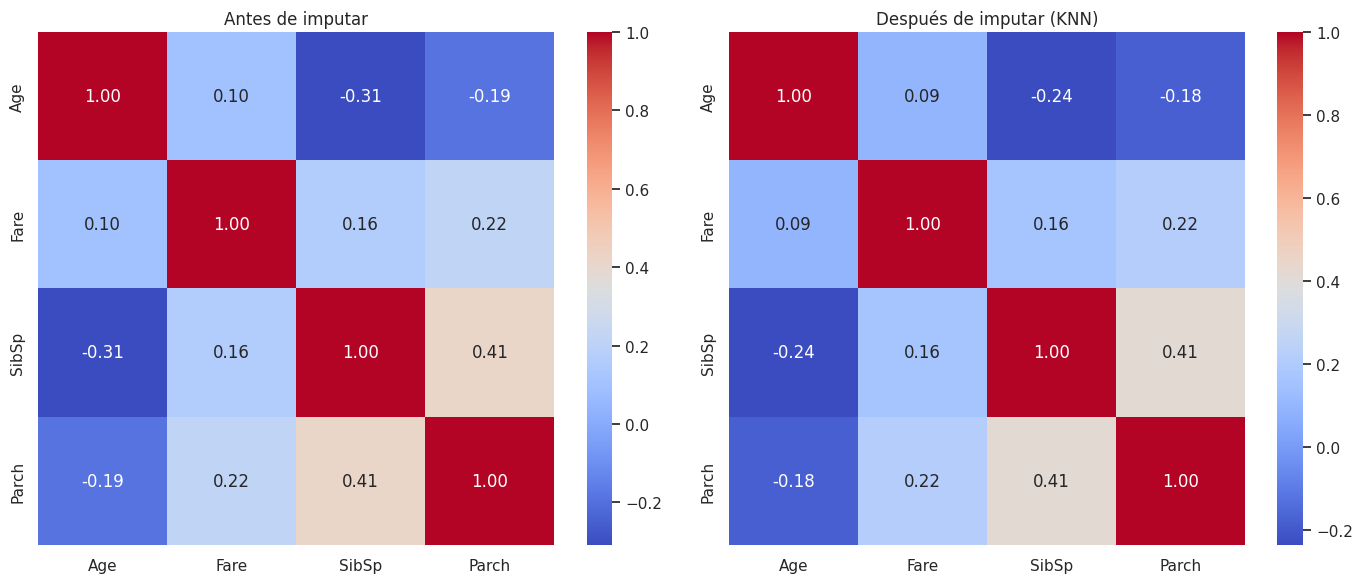

In [26]:

# -------------------------------------------------------------------
# 4. Imputación por K-Nearest Neighbors (KNN)
# -------------------------------------------------------------------
# Para KNN necesitamos solo variables numéricas
knn_df = data.copy()

# Codificamos variables categóricas simples para poder usarlas en KNN
knn_df["Sex"] = knn_df["Sex"].map({"male": 0, "female": 1})
knn_df["Embarked"] = knn_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
# Pclass ya es numérica

# Seleccionamos columnas a imputar con KNN
knn_cols = ["Age", "Embarked"]
knn_imputer = KNNImputer(n_neighbors=5)

knn_imputed_array = knn_imputer.fit_transform(knn_df[knn_cols])
knn_df_imputed = knn_df.copy()
knn_df_imputed[knn_cols] = knn_imputed_array

print("\nValores faltantes tras KNNImputer:")
print(knn_df_imputed[knn_cols].isna().sum())

# Seleccionamos columnas numéricas relevantes
num_cols = ["Age", "Fare", "SibSp", "Parch"]

corr_before = data[num_cols].corr()

corr_after = knn_df_imputed[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(corr_before, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Antes de imputar")

sns.heatmap(corr_after, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Después de imputar (KNN)")

plt.tight_layout()
plt.show()


Valores faltantes en Age tras regresión:
0


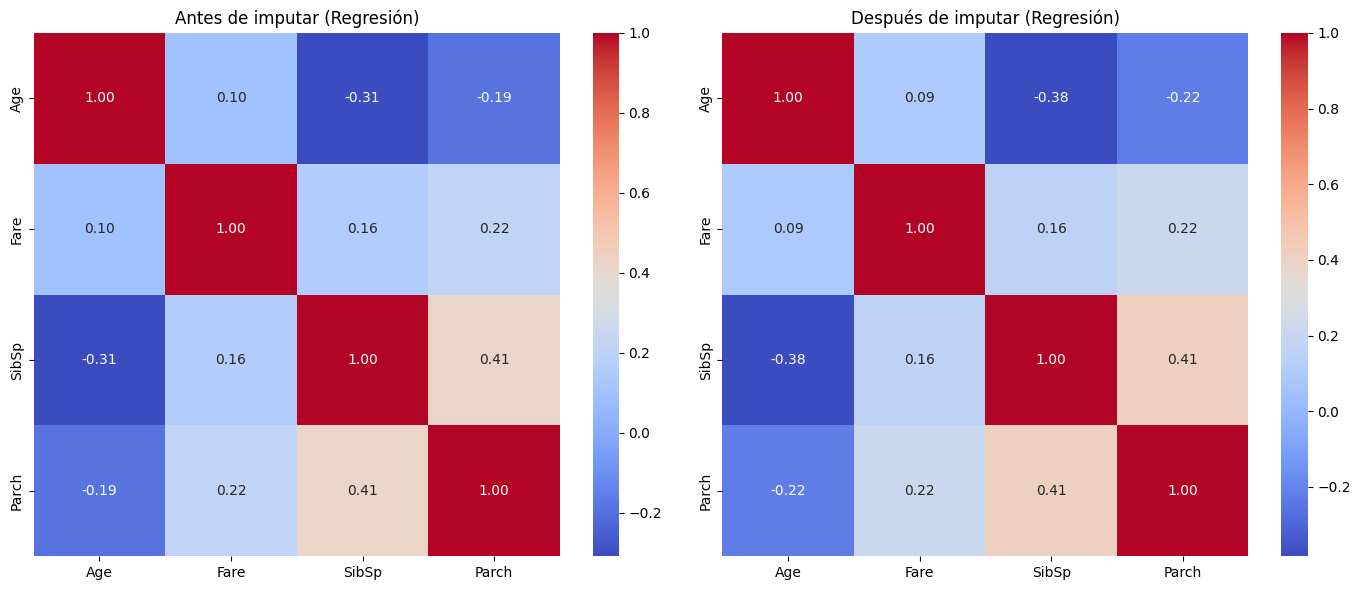

In [12]:
# -------------------------------------------------------------------
# 5. Imputación por regresión (ejemplo: predecir Age)
# -------------------------------------------------------------------
reg_df = data.copy()

# Usamos solo filas donde Age NO es nulo
train_reg = reg_df.dropna(subset=["Age"]).copy()
test_reg = reg_df[reg_df["Age"].isna()].copy()

# Codificación simple de variables categóricas
for col in ["Sex", "Embarked"]:
    train_reg[col] = train_reg[col].astype("category").cat.codes
    test_reg[col] = test_reg[col].astype("category").cat.codes

# Variables predictoras y objetivo
features = ["Pclass", "Sex", "SibSp", "Parch", "Fare", "Embarked"]
X_train = train_reg[features]
y_train = train_reg["Age"]

X_test = test_reg[features]

# Modelo de regresión lineal
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predicción de edades faltantes
predicted_ages = reg.predict(X_test)

# Rellenar en el DataFrame original
reg_df.loc[reg_df["Age"].isna(), "Age"] = predicted_ages

print("\nValores faltantes en Age tras regresión:")
print(reg_df["Age"].isna().sum())

# Grafico comparativo Antes y Después

num_cols = ["Age", "Fare", "SibSp", "Parch"]

corr_before_reg = data[num_cols].corr()

corr_after_reg = reg_df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(corr_before_reg, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Antes de imputar (Regresión)")

sns.heatmap(corr_after_reg, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Después de imputar (Regresión)")

plt.tight_layout()
plt.show()


In [13]:

# -------------------------------------------------------------------
# 6. Detección de outliers con IQR
# -------------------------------------------------------------------
def iqr_outliers(series, factor=1.5):
    """
    Devuelve un booleano indicando si cada valor es outlier
    según el criterio IQR.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper), lower, upper

age_outliers, age_lower, age_upper = iqr_outliers(data["Age"].dropna())
fare_outliers, fare_lower, fare_upper = iqr_outliers(data["Fare"].dropna())

print("\nIQR Age -> límites:", age_lower, age_upper)
print("Número de outliers en Age (IQR):", age_outliers.sum())
print("IQR Fare -> límites:", fare_lower, fare_upper)
print("Número de outliers en Fare (IQR):", fare_outliers.sum())



IQR Age -> límites: -6.6875 64.8125
Número de outliers en Age (IQR): 11
IQR Fare -> límites: -26.724 65.6344
Número de outliers en Fare (IQR): 116


In [27]:

# -------------------------------------------------------------------
# 7. Detección de outliers con z-score
# -------------------------------------------------------------------
# Usamos solo valores no nulos

age = data["Age"].dropna()
fare = data["Fare"].dropna()

age_z = stats.zscore(age)
fare_z = stats.zscore(fare)

# Umbral típico: |z| > 3
age_z_outliers = np.abs(age_z) > 3
fare_z_outliers = np.abs(fare_z) > 3

print("\nNúmero de outliers en Age (z-score>3):", age_z_outliers.sum())
print("Número de outliers en Fare (z-score>3):", fare_z_outliers.sum())



Número de outliers en Age (z-score>3): 2
Número de outliers en Fare (z-score>3): 20


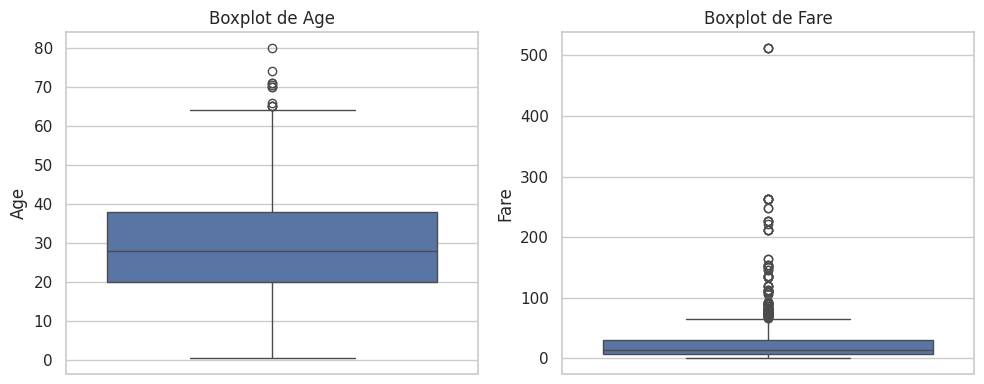

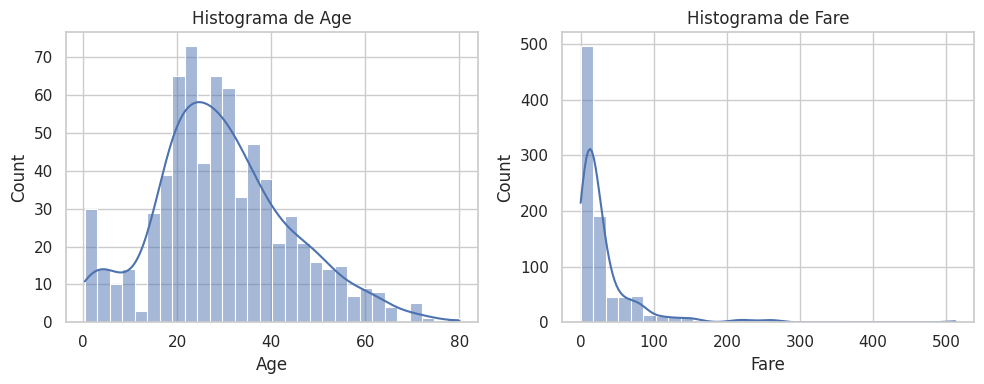

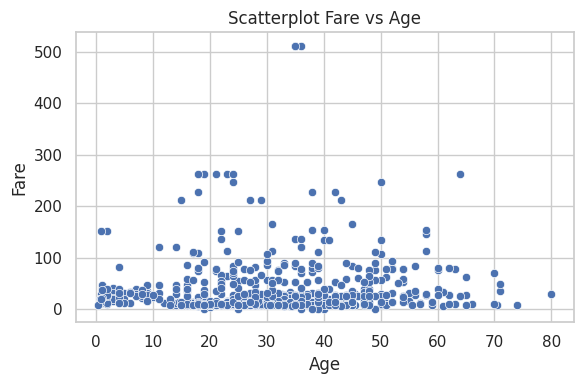

In [15]:

# -------------------------------------------------------------------
# 8. Visualización de outliers: boxplots, histogramas, scatterplots
# -------------------------------------------------------------------
sns.set(style="whitegrid")

# 8.1 Boxplots
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=data["Age"])
plt.title("Boxplot de Age")

plt.subplot(1, 2, 2)
sns.boxplot(y=data["Fare"])
plt.title("Boxplot de Fare")
plt.tight_layout()
plt.show()

# 8.2 Histogramas
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data["Age"], kde=True, bins=30)
plt.title("Histograma de Age")

plt.subplot(1, 2, 2)
sns.histplot(data["Fare"], kde=True, bins=30)
plt.title("Histograma de Fare")
plt.tight_layout()
plt.show()

# 8.3 Scatterplots (por ejemplo, Fare vs Age)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=data["Age"], y=data["Fare"])
plt.title("Scatterplot Fare vs Age")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()


In [16]:

# -------------------------------------------------------------------
# 9. Tratamiento de outliers
#    9.1 Eliminación de outliers (ejemplo con Fare usando IQR)
# -------------------------------------------------------------------
clean_df = data.copy()

fare_outliers_bool, fare_lower, fare_upper = iqr_outliers(clean_df["Fare"])
print("\nFilas antes de eliminar outliers en Fare:", clean_df.shape[0])

clean_df = clean_df[~fare_outliers_bool]  # eliminamos filas con outliers en Fare
print("Filas después de eliminar outliers en Fare:", clean_df.shape[0])


print("\n--- PROCESO COMPLETADO ---")


Filas antes de eliminar outliers en Fare: 891
Filas después de eliminar outliers en Fare: 775

--- PROCESO COMPLETADO ---
